In [1]:
# --- 1. Import Drive (Already in notebook, but re-including for completeness) ---
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# --- 2. Preparation (Data Loading and Prep - Already in notebook) ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
file_path = '/content/final.csv'
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

def map_quality_to_class(quality):
    if quality in [3, 4, 5]: return 0  # Bad
    elif quality in [6, 7, 8]: return 1  # Good
    return -1

df['quality_class'] = df['quality'].apply(map_quality_to_class)
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Dataset loaded successfully!
Training set size: 908, Test set size: 227


In [4]:
# --- 3. Making Base Model (Baseline Logistic Regression - Already in notebook) ---
print("\n--- Baseline Model: Logistic Regression ---")
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)
print("Baseline model training complete!")

# Baseline predictions and evaluation
y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print("\nBaseline Classification Report:")
target_names = ['Bad (Class 0)', 'Good (Class 1)']
print(classification_report(y_test, y_pred_baseline, target_names=target_names))


--- Baseline Model: Logistic Regression ---
Baseline model training complete!
Baseline Accuracy: 0.7269

Baseline Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.68      0.76      0.72       105
Good (Class 1)       0.77      0.70      0.73       122

      accuracy                           0.73       227
     macro avg       0.73      0.73      0.73       227
  weighted avg       0.73      0.73      0.73       227



In [5]:
# --- 4. Hyperparameter Tuning Steps (Grid Search Setup) ---
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],  # Optimization algorithm
    'max_iter': [100, 200, 300]  # Maximum iterations
}

# Note: 'elasticnet' requires 'saga' solver, and 'l1' requires 'liblinear' or 'saga'
# We'll handle compatibility in the next step
print("Parameter grid defined for hyperparameter tuning.")

Parameter grid defined for hyperparameter tuning.


In [6]:
# --- 5. Hyperparameter Tuning (Execute Grid Search) ---
# Create GridSearchCV object (use a subset if full grid is too large; here using full for demo)
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1  # Use all available cores
)

# Fit the grid search
print("Starting hyperparameter tuning...")
grid_search.fit(X_train, y_train)
print("Hyperparameter tuning complete!")

# Best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
Hyperparameter tuning complete!
Best parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation accuracy: 0.7278


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1170 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_so

In [7]:
# --- 6. Hyperparameter Tuning After Model (Train Tuned Model) ---
# Train the best model on full training data
tuned_model = LogisticRegression(**grid_search.best_params_, random_state=42)
tuned_model.fit(X_train, y_train)
print("Tuned model training complete!")

# Tuned model predictions and evaluation
y_pred_tuned = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Accuracy: {tuned_accuracy:.4f}")
print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

Tuned model training complete!
Tuned Accuracy: 0.7269

Tuned Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.68      0.76      0.72       105
Good (Class 1)       0.77      0.70      0.73       122

      accuracy                           0.73       227
     macro avg       0.73      0.73      0.73       227
  weighted avg       0.73      0.73      0.73       227




--- Model Comparison ---
      Model  Accuracy   ROC-AUC
0  Baseline  0.726872  0.807728
1     Tuned  0.726872  0.807260


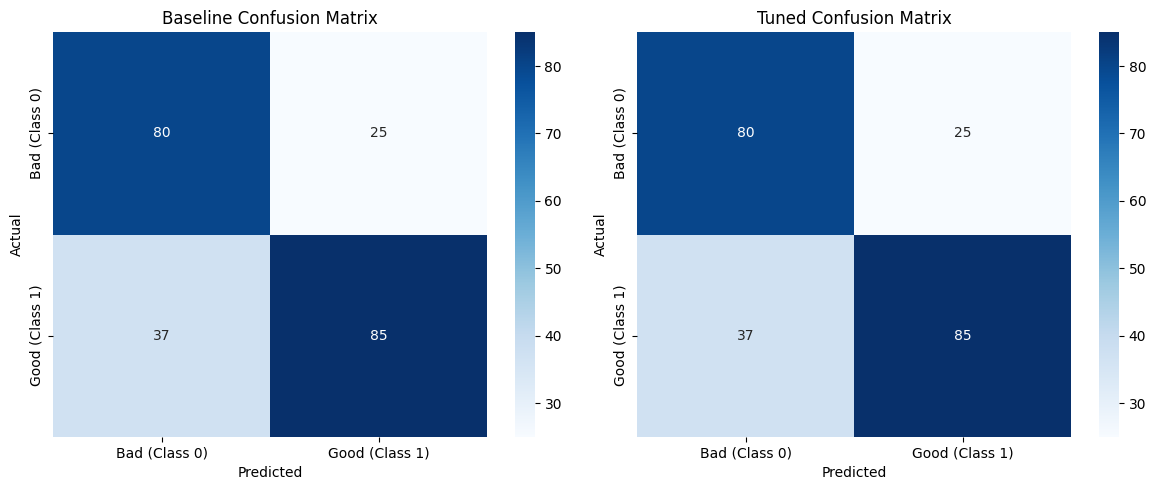

In [8]:
# --- 7. Baseline and Tuned Model Comparison ---
print("\n--- Model Comparison ---")
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'Accuracy': [baseline_accuracy, tuned_accuracy],
    'ROC-AUC': [roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:, 1]),
                roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:, 1])]
})

print(comparison_df)

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conf_baseline = confusion_matrix(y_test, y_pred_baseline)
conf_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(conf_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Baseline Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(conf_tuned, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title('Tuned Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

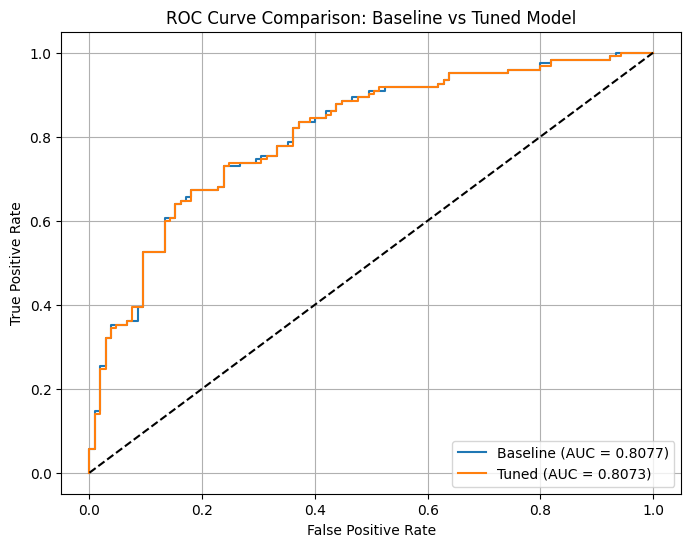

In [9]:
# --- 8. Graph (ROC Curves Comparison) ---
# Compute ROC curves
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_model.predict_proba(X_test)[:, 1])
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_baseline, tpr_baseline, label=f'Baseline (AUC = {roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:, 1]):.4f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Baseline vs Tuned Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [10]:
# --- 9. Prediction (Example on new data or test set) ---
# Predict on test set (already done, but re-showing)
print("\n--- Predictions on Test Set ---")
test_predictions = tuned_model.predict(X_test)
test_probabilities = tuned_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (Good)

# Example: Predict on a sample (first 5 test instances)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
print("\nSample predictions (Class: 0=Bad, 1=Good) and probabilities:")
for idx in sample_indices:
    print(f"Sample {idx}: Predicted Class = {test_predictions[idx]}, Probability (Good) = {test_probabilities[idx]:.4f}")


--- Predictions on Test Set ---

Sample predictions (Class: 0=Bad, 1=Good) and probabilities:
Sample 39: Predicted Class = 1, Probability (Good) = 0.5796
Sample 43: Predicted Class = 0, Probability (Good) = 0.3469
Sample 178: Predicted Class = 1, Probability (Good) = 0.6140
Sample 212: Predicted Class = 0, Probability (Good) = 0.1517
Sample 175: Predicted Class = 1, Probability (Good) = 0.5579
